# Implementation of Gradient Descent and its Varients from Scratch.

In [26]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
X,y = fetch_california_housing(return_X_y=True)

## Dataset Information 
Name : California Housing 
- It is a classical real life Regression dataset which is used to predict the median house prices based on 8 features(X).

`**Features (X)**`  
Each row corresponds to one block group(i.e. small geographical region). Features are:

1. MedInc → Median income in block group
    - Unit: 10,000s of dollars
    - Example: MedInc=3.5 means $35,000
2. HouseAge → Median house age in block group
    - Unit: years
3. AveRooms → Average number of rooms per household
4. AveBedrms → Average number of bedrooms per household
5. Population → Block group population
6. AveOccup → Average household members (population / households)
7. Latitude → Block group’s latitude (north–south position in California)
8. Longitude → Block group’s longitude (east–west position in California

`**Target (Y)**`
- MedHouseVal → Median house value (in 100,000s of dollars).
    - Example: y = 2.5 means median house price = $250,000.

In [27]:
feature_names = fetch_california_housing().feature_names
df = pd.DataFrame(X,columns=feature_names)
df["target"] = y

In [28]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [29]:
print("Shape of data is: ",df.shape)

Shape of data is:  (20640, 9)


In [30]:
## Checking for null values
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [31]:
## Statistical summary of the data 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
target,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


Text(0.5, 1.0, 'Distribution of Target var(Y)')

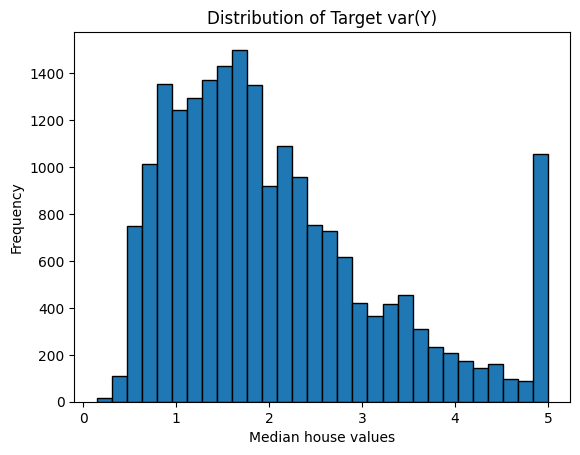

In [32]:
# plot to describe how Y is distributed
plt.hist(y,bins=30,edgecolor='black')
plt.xlabel('Median house values')
plt.ylabel('Frequency')
plt.title('Distribution of Target var(Y)')

In [33]:
## Standardizing the X and y
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
y=y.reshape(-1,1)
X_Scaled = scaler.fit_transform(X)
y_Scaled = scaler.fit_transform(y)

# “y is right-skewed; log-transforming could improve inference, but for the purpose of comparing GD methods, we keep y in original scale (after standardization).”

In [34]:
# OLS  
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_Scaled,y_Scaled,test_size=0.2)

In [36]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
print(lr.intercept_)
print(lr.coef_)

[0.00226463]
[[ 0.71970305  0.1036942  -0.23069436  0.26045656 -0.00676305 -0.0308584
  -0.7844525  -0.75863628]]


In [38]:
from sklearn.metrics import mean_squared_error,r2_score

## Implementation of Batch Gradient Descent from Scratch

In [39]:
class GDRegressor:
    def __init__(self,learning_rate=0.01,epochs=100):
        self.coef_ = None 
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs     
        self.loss_history=[]   
        
    def fit(self,X_train,y_train):
        """
        Fit linear regression model using Mini batch gradient descent.

        Parameters:

            X_train: np.ndarray (n_samples, n_features)
            y_train: np.ndarray (n_samples,) 1D array

        """
        n_samples, n_features = X_train.shape
        y_train = y_train.flatten()
        
        # initializing my coef(Weights) and intercept
        self.intercept_ = 0
        self.coef_ = np.zeros(n_features)

        # Update all the intercept_ and coef_
        for i in range(self.epochs):
            # Prediction
            y_hat = self.intercept_ + np.dot(X_train,self.coef_)

            # Compute gradiennts
            d_Coef = (-2/n_samples)*(X_train.T @ (y_train - y_hat))
            d_Intercept = (-2/n_samples)*np.sum(y_train-y_hat)

            # Update Parameters
            self.intercept_ = self.intercept_ - self.lr*d_Intercept
            self.coef_ = self.coef_ - self.lr*d_Coef

            # Compute and store loss
            loss = np.mean((y_train - y_hat) ** 2)
            self.loss_history.append(loss)

            # stop if loss explodes
            if np.isnan(loss) or np.isinf(loss):
                print(f"Divergence at epoch {i}, stopping training.")
                break

        print('Intercept is: ',self.intercept_)
        print('Coefficients are: ', self.coef_)

    def predict(self,X_test):
        '''  Predict tareget values for test data.

            Parameters:
            X_test: np.ndarray (n_samples, n_features)

        '''
        return self.intercept_ + np.dot(X_test,self.coef_)

In [40]:
BGD = GDRegressor(learning_rate=0.1,epochs=200)
BGD.fit(X_train,y_train)

Intercept is:  0.00223509668218581
Coefficients are:  [ 0.73080948  0.1100238  -0.24331925  0.26762697 -0.0045935  -0.0316246
 -0.72781225 -0.70294211]


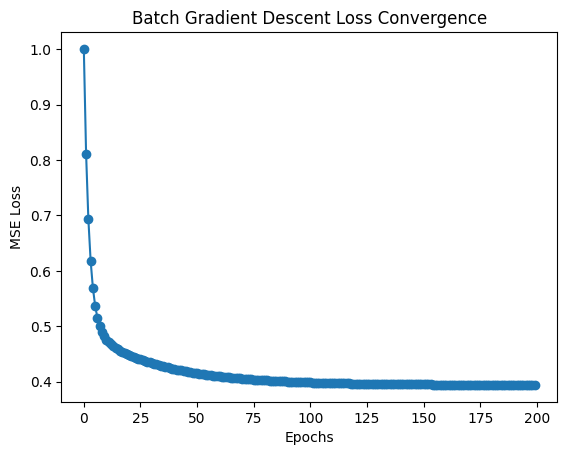

In [41]:
plt.plot(BGD.loss_history,marker='o')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Batch Gradient Descent Loss Convergence")
plt.show()

## Implementation of Stochastic Gradient Descent from scratch

In [42]:

class SGDRegressor:
    def __init__(self, learning_rate=0.001, epochs=50, shuffle=True):
        self.coef_ = None          # Weights for features
        self.intercept_ = None     # Intercept term
        self.lr = learning_rate
        self.epochs = epochs
        self.loss_history = []     # Store loss at each epoch
        self.shuffle = shuffle     # Whether to shuffle training data each epoch

    def fit(self, X_train, y_train):
        """
        Fit linear regression model using Mini batch gradient descent.

        Parameters:

            X_train: np.ndarray (n_samples, n_features)
            y_train: np.ndarray (n_samples,) 1D array

        """
        n_samples, n_features = X_train.shape

        # Ensure y is 1D
        y_train = y_train.flatten()

        # Initialize weights and intercept
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0

        for epoch in range(self.epochs):
            # shuffle data each epoch
            if self.shuffle:
                indices = np.arange(n_samples)
                np.random.shuffle(indices)
                X_train, y_train = X_train[indices], y_train[indices]

            # Loop over each sample for SGD
            for i in range(n_samples):
                xi = X_train[i]       # shape (n_features,)
                yi = y_train[i]       # scalar
                y_hat_i = self.intercept_ + np.dot(xi, self.coef_)

                # Gradients for this sample
                d_Coef = -2 * xi * (yi - y_hat_i)
                d_Intercept = -2 * (yi - y_hat_i)

                # Update parameters
                self.intercept_ = self.intercept_ - self.lr*d_Intercept
                self.coef_ = self.coef_ - self.lr*d_Coef

            # Compute and store MSE loss over all samples at end of epoch
            y_hat = self.intercept_ + np.dot(X_train, self.coef_)
            loss = np.mean((y_train - y_hat) ** 2)
            self.loss_history.append(loss)

            # stop if loss explodes
            if np.isnan(loss) or np.isinf(loss):
                print(f"Divergence at epoch {epoch}, stopping training.")
                break

        print("Intercept:", self.intercept_)
        print("Coefficients:", self.coef_)

    def predict(self, X_test):
        '''  Predict tareget values for test data.

            Parameters:
            X_test: np.ndarray (n_samples, n_features)

        '''
        return self.intercept_ + np.dot(X_test, self.coef_)


In [ ]:
SGD = SGDRegressor(learning_rate=0.0001,epochs=120)
SGD.fit(X_train,y_train)

Intercept: 0.007865626243778272
Coefficients: [ 0.7076107   0.10847277 -0.20561065  0.2538103  -0.00852144 -0.03749517
 -0.78490386 -0.75985288]


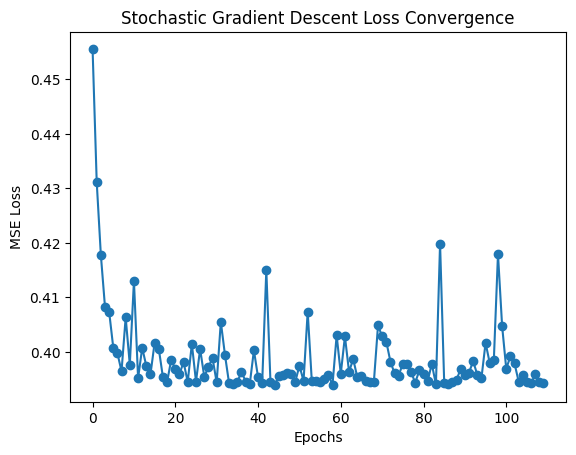

In [51]:

plt.plot(SGD.loss_history,marker='o')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Stochastic Gradient Descent Loss Convergence")
plt.show()


## Implementation of Mini Batch GD from scratch

In [45]:
import random
class MBGDRegressor:
    def __init__(self,batch_size=20,learning_rate=0.01,epochs=100, shuffle = True):
        self.coef_ = None 
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs   
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.loss_history=[]   
        
    def fit(self,X_train,y_train):
        """
        Fit linear regression model using Mini batch gradient descent.

        Parameters:

            X_train: np.ndarray (n_samples, n_features)
            y_train: np.ndarray (n_samples,) 1D array

        """
        n_samples, n_features = X_train.shape
        y_train = y_train.flatten()
        
        # initializing my coef(Weights) and intercept
        self.intercept_ = 0
        self.coef_ = np.zeros(n_features)

        # Update all the intercept_ and coef_
        for i in range(self.epochs):
             # shuffle data each epoch
            if self.shuffle:
                indices = np.arange(n_samples)
                np.random.shuffle(indices)
                X_train, y_train = X_train[indices], y_train[indices]


            for j in range(0,n_samples,self.batch_size):

                X_batch = X_train[j:j+self.batch_size]
                y_batch = y_train[j:j+self.batch_size]

                # Prediction
                y_hat = self.intercept_ + np.dot(X_batch,self.coef_)

                # Compute gradiennts
                d_Coef = (-2/len(y_batch))*(X_batch.T @ (y_batch - y_hat))
                d_Intercept = (-2/len(y_batch))*np.sum(y_batch-y_hat)

                # Update Parameters
                self.intercept_ = self.intercept_ - self.lr*d_Intercept
                self.coef_ = self.coef_ - self.lr*d_Coef

            # Compute and store loss
            y_pred = self.intercept_ + X_train @ self.coef_
            loss = np.mean((y_train - y_pred) ** 2)
            self.loss_history.append(loss)

            # stop if loss explodes
            if np.isnan(loss) or np.isinf(loss):
                print(f"Divergence at epoch {i}, stopping training.")
                break

        print('Intercept is: ',self.intercept_)
        print('Coefficients are: ', self.coef_)

    def predict(self,X_test):
        '''  Predict tareget values for test data.

            Parameters:
            X_test: np.ndarray (n_samples, n_features)

        '''
        return self.intercept_ + (X_test @ self.coef_)

In [46]:
MBGd = MBGDRegressor(batch_size=128,learning_rate=0.001,epochs=100)
MBGd.fit(X_train,y_train)


Intercept is:  0.0023402958741748116
Coefficients are:  [ 7.31330620e-01  1.20439230e-01 -2.25967114e-01  2.44091313e-01
 -6.97063889e-04 -3.19246912e-02 -6.52711519e-01 -6.27084578e-01]


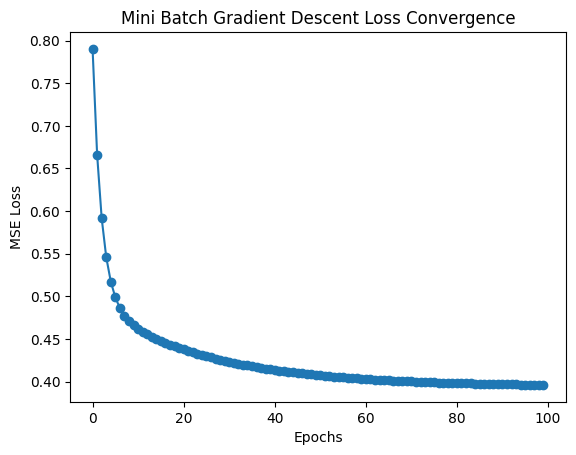

In [47]:
plt.plot(MBGd.loss_history,marker='o')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Mini Batch Gradient Descent Loss Convergence")
plt.show()

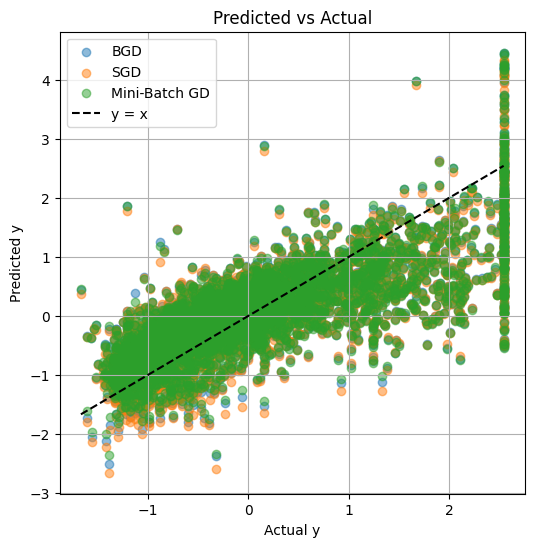

In [48]:
# Predicted vs actual Scatter plot for different gradient descent variants.
y_pred_bgd = BGD.predict(X_test)     
y_pred_sgd = SGD.predict(X_test)     
y_pred_mbgd = MBGd.predict(X_test) 

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_bgd, alpha=0.5, label='BGD')
plt.scatter(y_test, y_pred_sgd, alpha=0.5, label='SGD')
plt.scatter(y_test, y_pred_mbgd, alpha=0.5, label='Mini-Batch GD')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='y = x')
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Predicted vs Actual")
plt.grid(True)
plt.legend()
plt.show()

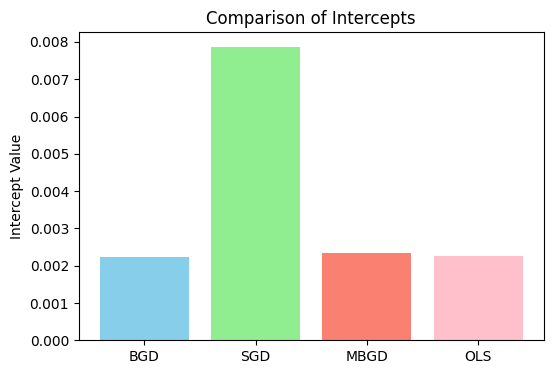

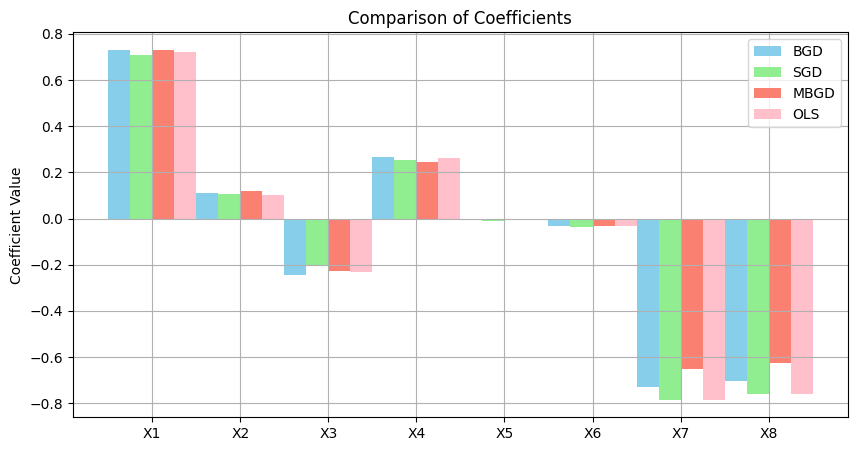

In [52]:
lr.intercept_ = float(lr.intercept_)
intercepts = [BGD.intercept_, SGD.intercept_, MBGd.intercept_,lr.intercept_]
coefs = [BGD.coef_, SGD.coef_, MBGd.coef_, lr.coef_.flatten()]

model_names = ['BGD', 'SGD', 'MBGD','OLS']   # used for plotting
n_features = len(coefs[0])
feature_names = [f'X{i+1}' for i in range(n_features)]  # name features X1, X2, ...

# Plotting Intercepts
plt.figure(figsize=(6,4))
plt.bar(model_names, intercepts, color=['skyblue', 'lightgreen', 'salmon','pink'])
plt.ylabel("Intercept Value")
plt.title("Comparison of Intercepts")
plt.show()

# Plotting Coefficients
x = np.arange(n_features)  # positions for each feature
width = 0.25               # width of each bar

plt.figure(figsize=(10,5))
plt.bar(x-1.5*width, coefs[0], width, label='BGD', color='skyblue')
plt.bar(x-0.5*width, coefs[1], width, label='SGD', color='lightgreen')
plt.bar(x+0.5*width, coefs[2], width, label='MBGD', color='salmon')
plt.bar(x+1.5*width, coefs[3], width, label='OLS', color='pink',)

plt.xticks(x, feature_names)
plt.ylabel("Coefficient Value")
plt.title("Comparison of Coefficients")
plt.grid(True)
plt.legend()
plt.show()